This notebook generates summary and figures for 'Genes that are most commonly co-expressed with BGCs' section. 

In [246]:
import pandas as pd
import numpy as np

In [247]:
file_path = '/Users/annasve/Desktop/article_data/output/iterative_WGCNA/analysis/bgc_modules_refined.xlsx'
bgc_modules = pd.read_excel(file_path)

In [248]:
bgc_modules

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cluster_Product_6,Cand_Cluster_7,Cluster_Product_7,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup
0,OHB55_00010,hypothetical protein,100.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Singleton
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851
4,OHB55_00205,hypothetical protein,75.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0008630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67815,OIE62_40710,TauD/TfdA family dioxygenase,333.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0001597
67816,OIE62_40715,FAD-binding protein,517.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0012951
67817,OIE62_40720,glycosyltransferase family 4 protein,417.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0017394
67818,OIE62_40725,glycosyltransferase family 4 protein,348.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0004890


In [249]:
bgc_modules.columns

Index(['Geneid', 'Product', 'Sequence_Length', 'Gene_Kind', 'Is_Core_Gene',
       'Region_Nr', 'corr_to_bgc', 'expressed_any', 'high_corr',
       'refined_member', 'refined_BGC_ID', 'Module', 'kME', 'Cand_Cluster_1',
       'Cluster_Product_1', 'Cand_Cluster_2', 'Cluster_Product_2',
       'Cand_Cluster_3', 'Cluster_Product_3', 'Cand_Cluster_4',
       'Cluster_Product_4', 'prediction', 'score', 'Description',
       'Preferred_name', 'COG_category', 'PFAMs', 'KEGG_Module', 'CAI', 'CBI',
       'Strain', 'Group_ID', 'Locus_ID', 'Overlap_Lengths', 'Strain_Module',
       'motif_id', 'motif_name', 'start', 'site_sequence', 'E_value',
       'significant_site', 'BGC_region', 'BGC_block', '__gorder__',
       'low_expression_rule', 'Region_Nr_original', 'Cand_Cluster_5',
       'Cluster_Product_5', 'Cand_Cluster_6', 'Cluster_Product_6',
       'Cand_Cluster_7', 'Cluster_Product_7', 'Cand_Cluster_8',
       'Cluster_Product_8', 'Cand_Cluster_9', 'Cluster_Product_9',
       'Cand_Cluster_1

In [250]:
file_path = '/Users/annasve/Desktop/article_data/output/iterative_WGCNA/analysis/fishers_001_refined_purity.xlsx'
fishers = pd.read_excel(file_path)

In [251]:
fishers["Strain_Module"] = fishers["Strain"].astype(str) + "_" + fishers["Module"].astype(str)

In [252]:
fishers.head()

,BGC_ID,Module,a_in_bgc_in_module,bgc_size,module_size,strain_genes,odds_ratio,p_value,Strain,BGC_type,FDR,bgc_coverage,module_purity,Strain_Module
0,NBC_01518_34_redox-cofactor,P1_I37_M31,6,11,120,10594,110.200000,8.217137e-10,NBC_01518,refined,3.190506e-08,0.545455,0.050000,NBC_01518_P1_I37_M31
1,NBC_00438_41_other_oligosaccharide,P3_I16_M113,2,3,40,9585,502.315789,5.081095e-05,NBC_00438,refined,8.308139e-04,0.666667,0.050000,NBC_00438_P3_I16_M113
2,NBC_01104_6_NRPS-like_NRPS,P1_I31_M38,8,15,158,7825,58.361905,1.321263e-10,NBC_01104,refined,5.632052e-09,0.533333,0.050633,NBC_01104_P1_I31_M38
3,NBC_00114_11_ectoine,P1_I14_M114,4,4,79,8525,inf,6.832099e-09,NBC_00114,refined,2.348518e-07,1.000000,0.050633,NBC_00114_P1_I14_M114
4,NBC_00805_8_ectoine,P1_I21_M55,4,4,79,6431,inf,2.110169e-08,NBC_00805,refined,6.737526e-07,1.000000,0.050633,NBC_00805_P1_I21_M55


In [253]:
fishers = fishers[["BGC_ID", "Strain_Module"]].rename(columns={"BGC_ID": "relevant_BGC_ID"})

In [254]:
fishers = (
    fishers.groupby("Strain_Module")["relevant_BGC_ID"]
      .apply(lambda s: ",".join(sorted(s.astype(str).unique())))
      .reset_index()
)


In [255]:
fishers

,Strain_Module,relevant_BGC_ID
0,NBC_00001_P1_I26_M17,NBC_00001_2_NRP-metallophore_NRPS
1,NBC_00001_P1_I26_M38,NBC_00001_23_NI-siderophore
2,NBC_00001_P1_I26_M78,NBC_00001_26_ectoine
3,NBC_00001_P2_I9_M21,NBC_00001_22_thioamitides
4,NBC_00003_P1_I23_M20,NBC_00003_50_NI-siderophore
...,...,...
890,NBC_01815_P10_I1_M1,NBC_01815_10_NRPS-like_butyrolactone_T1PKS_NRPS
891,NBC_01815_P10_I1_M2,NBC_01815_17_T1PKS
892,NBC_01815_P1_I34_M2,NBC_01815_21_transAT-PKS_NRPS-like_NRPS_PKS-like
893,NBC_01815_P1_I34_M42,NBC_01815_24_RiPP-like_NRPS


In [256]:
bgc_modules = pd.merge(bgc_modules, fishers, how = 'left', on = 'Strain_Module')

In [257]:
bgc_modules

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cand_Cluster_7,Cluster_Product_7,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup,relevant_BGC_ID
0,OHB55_00010,hypothetical protein,100.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Singleton,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840,NBC_01734_17_T3PKS
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
4,OHB55_00205,hypothetical protein,75.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0008630,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67815,OIE62_40710,TauD/TfdA family dioxygenase,333.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0001597,NBC_01770_18_ectoine
67816,OIE62_40715,FAD-binding protein,517.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0012951,NBC_01770_18_ectoine
67817,OIE62_40720,glycosyltransferase family 4 protein,417.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0017394,NBC_01770_18_ectoine
67818,OIE62_40725,glycosyltransferase family 4 protein,348.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0004890,NBC_01770_18_ectoine


In [258]:
bgc_modules.columns

Index(['Geneid', 'Product', 'Sequence_Length', 'Gene_Kind', 'Is_Core_Gene',
       'Region_Nr', 'corr_to_bgc', 'expressed_any', 'high_corr',
       'refined_member', 'refined_BGC_ID', 'Module', 'kME', 'Cand_Cluster_1',
       'Cluster_Product_1', 'Cand_Cluster_2', 'Cluster_Product_2',
       'Cand_Cluster_3', 'Cluster_Product_3', 'Cand_Cluster_4',
       'Cluster_Product_4', 'prediction', 'score', 'Description',
       'Preferred_name', 'COG_category', 'PFAMs', 'KEGG_Module', 'CAI', 'CBI',
       'Strain', 'Group_ID', 'Locus_ID', 'Overlap_Lengths', 'Strain_Module',
       'motif_id', 'motif_name', 'start', 'site_sequence', 'E_value',
       'significant_site', 'BGC_region', 'BGC_block', '__gorder__',
       'low_expression_rule', 'Region_Nr_original', 'Cand_Cluster_5',
       'Cluster_Product_5', 'Cand_Cluster_6', 'Cluster_Product_6',
       'Cand_Cluster_7', 'Cluster_Product_7', 'Cand_Cluster_8',
       'Cluster_Product_8', 'Cand_Cluster_9', 'Cluster_Product_9',
       'Cand_Cluster_1

In [259]:
bgc_modules_filtered = bgc_modules[bgc_modules["refined_BGC_ID"].isna()]

In [261]:
#bgc_modules_filtered = bgc_modules_filtered.drop(columns=["Unnamed: 0"])

In [262]:
bgc_modules_filtered

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cand_Cluster_7,Cluster_Product_7,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup,relevant_BGC_ID
0,OHB55_00010,hypothetical protein,100.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Singleton,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840,NBC_01734_17_T3PKS
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
4,OHB55_00205,hypothetical protein,75.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0008630,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67814,OIE62_40705,hypothetical protein,468.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0015569,NBC_01770_18_ectoine
67815,OIE62_40710,TauD/TfdA family dioxygenase,333.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0001597,NBC_01770_18_ectoine
67816,OIE62_40715,FAD-binding protein,517.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0012951,NBC_01770_18_ectoine
67817,OIE62_40720,glycosyltransferase family 4 protein,417.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0017394,NBC_01770_18_ectoine


In [263]:
bgc_modules_filtered.to_excel('bgc_module_check.xlsx')

In [264]:
# ---- COG full names (standard) ----
COG_FULLNAME = {
    "A": "RNA processing/modification",
    "B": "Chromatin structure",
    "C": "Energy production",
    "D": "Cell cycle control",
    "E": "Amino acid transport/metabolism",
    "F": "Nucleotide transport/metabolism",
    "G": "Carbohydrate transport/metabolism",
    "H": "Coenzyme transport/metabolism",
    "I": "Lipid transport/metabolism",
    "J": "Translation",
    "K": "Transcription",
    "L": "Replication/recombination/repair",
    "M": "Cell wall biogenesis",
    "N": "Cell motility",
    "O": "Posttranslational modification",
    "P": "Inorganic ion transport/metabolism",
    "Q": "Secondary metabolite biosynthesis",
    "R": "General function prediction only",
    "S": "Function unknown",
    "T": "Signal transduction",
    "U": "Intracellular trafficking",
    "V": "Defense mechanisms",
    "W": "Extracellular structures",
    "Y": "Nuclear structure",
    "Z": "Cytoskeleton",
    "NA": "Unassigned / no COG",
}

# ---- Fixed colors (HEX) for reproducibility ----
# You can change any hex value and it will stay stable forever.
COG_COLOR = {
    "A": "#1f77b4",
    "B": "#aec7e8",
    "C": "#ff7f0e",
    "D": "#ffbb78",
    "E": "#2ca02c",
    "F": "#98df8a",
    "G": "#d62728",
    "H": "#ff9896",
    "I": "#9467bd",
    "J": "#c5b0d5",
    "K": "#8c564b",
    "L": "#c49c94",
    "M": "#e377c2",
    "N": "#f7b6d2",
    "O": "#7f7f7f",
    "P": "#c7c7c7",
    "Q": "#bcbd22",
    "R": "#dbdb8d",
    "S": "#17becf",
    "T": "#9edae5",
    "U": "#393b79",
    "V": "#637939",
    "W": "#8c6d31",
    "Y": "#843c39",
    "Z": "#7b4173",
    "NA": "#000000",
}

# A stable order for legend / consistent appearance
COG_ORDER = [
    "A","B","C","D","E","F","G","H","I","J","K","L",
    "M","N","O","P","Q","R","S","T","U","V","W","Y","Z","NA"
]


In [265]:
import matplotlib.patches as mpatches

def make_cog_legend_handles(cogs_present):
    cogs_present = set(cogs_present)
    handles = []
    for c in COG_ORDER:
        if c in cogs_present:
            label = COG_FULLNAME.get(c, "Unassigned / no COG")
            handles.append(
                mpatches.Patch(
                    color=COG_COLOR.get(c, COG_COLOR["NA"]),
                    label=label
                )
            )
    return handles


In [266]:
PRODUCT_RENAME = {
    "helix-turn-helix domain-containing protein": "HTH domain-containing protein",
    "helix-turn-helix transcriptional regulator": "HTH TR",
    "TetR/AcrR family transcriptional regulator": "TetR TR",
    "GntR family transcriptional regulator": "GntR TR",
    "LysR family transcriptional regulator": "LysR TR",
    "MarR family transcriptional regulator": "MarR TR",
    "MerR family transcriptional regulator": "MerR TR",
    "LacI family transcriptional regulator": "LacI TR",
    "sigma-70 family RNA polymerase sigma factor": "σ70 sigma factor",
    "class I SAM-dependent methyltransferase": "class I SAM methyltransferase",
    "FAD-dependent oxidoreductase": "FAD oxidoreductase",
    "FAD-dependent monooxygenase": "FAD monooxygenase",
    "SDR family oxidoreductase": "SDR oxidoreductase",
    "SDR family NAD(P)-dependent oxidoreductase": "SDR family NAD(P) oxidoreductase",
    "response regulator transcription factor": "response regulator TF",
    "ATP-binding cassette domain-containing protein": "ATP-binding cassette",
    "iron chelate uptake ABC transporter family permease subunit": "iron chelate uptake ABC transporter",
    "LLM class flavin-dependent oxidoreductase": "LLM flavin oxidoreductase",
    "Lrp/AsnC family transcriptional regulator": "Lrp/AsnC TR",
    "ABC transporter ATP-binding protein/permease": "ABC transporter ATP-binding permease",
    "methyltransferase domain-containing protein": "methyltransferase",
    "pyridoxamine 5'-phosphate oxidase family protein": "pyridoxamine 5'-phosphate oxidase",
    "NADP-dependent oxidoreductase": "NADP oxidoreductase",
}


In [267]:
s = bgc_modules_filtered["relevant_BGC_ID"].dropna().astype(str)

print("Any comma-separated entries?:", s.str.contains(",").any())
print("Examples with comma:")
print(s[s.str.contains(",")].head(5))

print("Any comma+space pattern?:", s.str.contains(r",\s+").any())


Any comma-separated entries?: True
Examples with comma:
1729    NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_...
1731    NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_...
1732    NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_...
1738    NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_...
1741    NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_...
Name: relevant_BGC_ID, dtype: object
Any comma+space pattern?: False


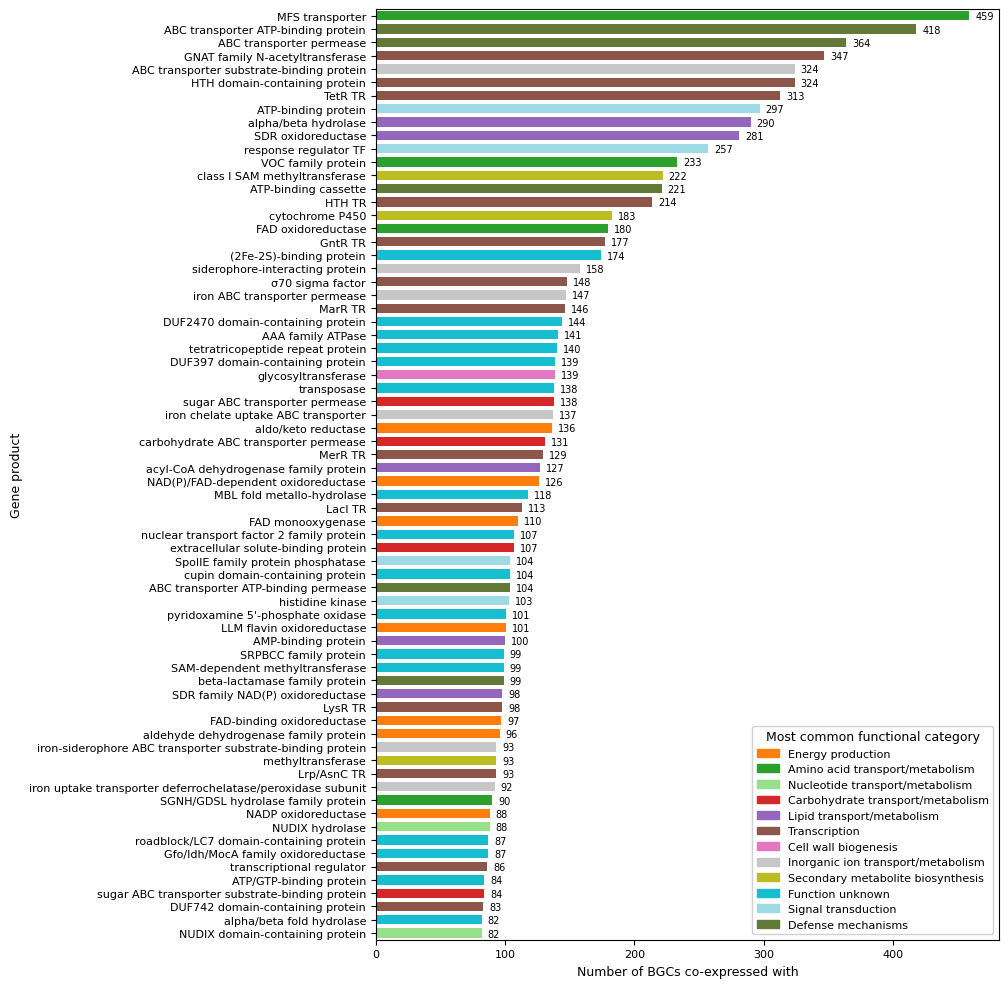

,Product,n_BGCs,top_COG,Product_label
69,NUDIX domain-containing protein,82,F,NUDIX domain-containing protein
68,alpha/beta fold hydrolase,82,S,alpha/beta fold hydrolase
67,DUF742 domain-containing protein,83,K,DUF742 domain-containing protein
66,sugar ABC transporter substrate-binding protein,84,G,sugar ABC transporter substrate-binding protein
65,ATP/GTP-binding protein,84,S,ATP/GTP-binding protein
...,...,...,...,...
4,ABC transporter substrate-binding protein,324,P,ABC transporter substrate-binding protein
3,GNAT family N-acetyltransferase,347,K,GNAT family N-acetyltransferase
2,ABC transporter permease,364,V,ABC transporter permease
1,ABC transporter ATP-binding protein,418,V,ABC transporter ATP-binding protein


In [268]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from textwrap import shorten

TOP_N = 70   # 👈 change this to 30, 40, 50, etc.

df_in = bgc_modules_filtered.copy()

import pandas as pd

# -----------------------------
# 1) Keep only genes linked to ≥1 BGC (and explode if multiple BGCs per cell)
# -----------------------------
d = df_in.copy()

# Keep only rows with a BGC assignment
d = d[d["relevant_BGC_ID"].notna()].copy()

# If relevant_BGC_ID can contain multiple BGCs separated by commas, split+explode
d["relevant_BGC_ID"] = d["relevant_BGC_ID"].astype("string")
d["relevant_BGC_ID"] = d["relevant_BGC_ID"].str.split(r"\s*,\s*")
d = d.explode("relevant_BGC_ID", ignore_index=True)

# Clean up possible empty strings after splitting
d["relevant_BGC_ID"] = d["relevant_BGC_ID"].astype("string").str.strip()
d = d[d["relevant_BGC_ID"].notna() & (d["relevant_BGC_ID"] != "")].copy()

# -----------------------------
# 2) Clean Product and remove bad/hypothetical annotations
# -----------------------------
d["Product"] = d["Product"].astype("string").str.strip()

bad_products = {"", "-", "nan", "none", "na", "null", "<na>"}
d = d[
    d["Product"].notna()
    & (~d["Product"].str.lower().isin(bad_products))
    & (d["Product"].str.lower() != "hypothetical protein")
].copy()

# -----------------------------
# 3) Extract single-letter COG category (A–Z), else NA
# -----------------------------
d["COG1"] = (
    d.get("COG_category", pd.Series([pd.NA] * len(d), index=d.index))
     .astype("string")
     .str.extract(r"([A-Z])", expand=False)
     .fillna("NA")
)


# 4) Count DISTINCT BGCs per Product
product_counts = (
    d.groupby("Product")["relevant_BGC_ID"]
     .nunique()
     .reset_index(name="n_BGCs")
     .sort_values("n_BGCs", ascending=False)
)


# 5) Most common COG per Product (still based on genes)
top_cog = (
    d.groupby("Product")["COG1"]
     .agg(lambda s: s.value_counts().idxmax())
     .reset_index(name="top_COG")
)

summary = product_counts.merge(top_cog, on="Product", how="left")
summary["top_COG"] = summary["top_COG"].fillna("NA")


summary = product_counts.merge(top_cog, on="Product", how="left")
summary["top_COG"] = summary["top_COG"].fillna("NA")


# -----------------------------
# 6) Select Top N and plot
# -----------------------------
topN = summary.head(TOP_N).sort_values("n_BGCs", ascending=True).copy()

# Manual renaming (then optional shortening)
topN["Product_label"] = topN["Product"].replace(PRODUCT_RENAME)

# (Optional) shorten anything still too long
# topN["Product_label"] = topN["Product_label"].apply(lambda x: shorten(str(x), width=45, placeholder="…"))

# --- COLORS: use your fixed palette so legend matches bars ---
topN["top_COG"] = topN["top_COG"].fillna("NA")
bar_colors = [COG_COLOR.get(c, COG_COLOR["NA"]) for c in topN["top_COG"]]

# --- Plot ---
# --- Plot ---
fig_h = max(5, 0.14 * TOP_N)      # ↓ smaller per-bar space (less whitespace)
fig, ax = plt.subplots(figsize=(10, fig_h))

bars = ax.barh(
    topN["Product_label"],
    topN["n_BGCs"],
    color=bar_colors,
    height=0.70,                  # ↓ thinner bars but still tight
    edgecolor="none"
)

ax.set_xlabel("Number of BGCs co-expressed with", fontsize=9)
ax.set_ylabel("Gene product", fontsize=9)

ax.margins(y=0.01)
ax.set_ylim(-0.5, len(topN) - 0.5)  # keeps first/last bars aligned (prevents centering weirdness)

# Reduce extra padding above/below the first/last bar
ax.margins(y=0.01)

# --- 1) VALUE LABELS: align to the TOP of the bar (and consistent) ---
# Use bar geometry rather than enumerate (fixes misalignment)
x_offset = max(topN["n_BGCs"]) * 0.01
for b in bars:
    w = b.get_width()
    y_top = b.get_y() + b.get_height() - 0.02  # near top of bar
    ax.text(w + x_offset, y_top, f"{int(w)}", va="top", ha="left", fontsize=7)

# --- 3) LEGEND: only categories present + matching colors ---
present_cogs = list(pd.unique(topN["top_COG"]))
handles = [
    mpatches.Patch(color=COG_COLOR.get(c, COG_COLOR["NA"]), label=COG_FULLNAME.get(c, "Unassigned / no COG"))
    for c in COG_ORDER
    if c in present_cogs
]

ax.legend(
    handles=handles,
    title="Most common functional category",
    loc="lower right",
    frameon=True,
    framealpha=0.9,
    fontsize=8,
    title_fontsize=9
)

# Smaller tick labels
ax.tick_params(axis="y", labelsize=8)
ax.tick_params(axis="x", labelsize=8)

plt.tight_layout(pad=0.4)

plt.savefig(
    "Top65_products_BGCs.png",
    dpi=350,
    bbox_inches="tight"
) 

plt.show()

topN


In [269]:
d

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cluster_Product_7,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup,relevant_BGC_ID,COG1
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,N
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840,NBC_01734_17_T3PKS,K
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,L
7,OHB55_00250,threonine/serine dehydratase,313.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0005006,NBC_01734_5_RRE-containing_NRP-metallophore_NR...,E
9,OHB55_00320,phage Gp37/Gp68 family protein,251.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0008945,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61640,OIE62_38505,GNAT family N-acetyltransferase,36.0,unknown,False,33.0,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0001271,NBC_01770_18_ectoine,S
61643,OIE62_40710,TauD/TfdA family dioxygenase,333.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0001597,NBC_01770_18_ectoine,Q
61644,OIE62_40715,FAD-binding protein,517.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0012951,NBC_01770_18_ectoine,E
61645,OIE62_40720,glycosyltransferase family 4 protein,417.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0017394,NBC_01770_18_ectoine,M


In [270]:
product_bgc_summary.head()

,Product,n_genes,n_BGCs,BGC_IDs,BGC_types,BGC_type_counts
3138,hypothetical protein,10007,937,"NBC_00001_22_thioamitides,NBC_00001_23_NI-side...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRPS:683; NI-siderophore:592; terpene:580; T2P...
1399,MFS transporter,896,459,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_10...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRPS:64; T2PKS:52; T1PKS:51; NI-siderophore:48...
217,ABC transporter ATP-binding protein,801,418,"NBC_00001_23_NI-siderophore,NBC_00003_22_thioa...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRP-metallophore_NRPS:112; NI-siderophore:101;...
220,ABC transporter permease,684,364,"NBC_00001_22_thioamitides,NBC_00001_23_NI-side...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",terpene:44; NRPS:44; T1PKS:36; NI-siderophore:...
1159,GNAT family N-acetyltransferase,620,347,"NBC_00003_10_NRPS-like_T3PKS,NBC_00003_50_NI-s...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NI-siderophore:50; NRP-metallophore_NRPS:49; N...


In [271]:
top_cog.head()

,Product,top_COG
0,"(2,3-dihydroxybenzoyl)adenylate synthase",Q
1,(2Fe-2S) ferredoxin domain-containing protein,C
2,(2Fe-2S)-binding protein,S
3,(4Fe-4S)-binding protein,S
4,(5-formylfuran-3-yl)methyl phosphate synthase,S


In [272]:
product_bgc_summary = pd.merge(product_bgc_summary, top_cog, how = 'left', on = 'Product')

In [273]:
product_bgc_summary.head()

,Product,n_genes,n_BGCs,BGC_IDs,BGC_types,BGC_type_counts,top_COG
0,hypothetical protein,10007,937,"NBC_00001_22_thioamitides,NBC_00001_23_NI-side...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRPS:683; NI-siderophore:592; terpene:580; T2P...,<NA>
1,MFS transporter,896,459,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_10...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRPS:64; T2PKS:52; T1PKS:51; NI-siderophore:48...,E
2,ABC transporter ATP-binding protein,801,418,"NBC_00001_23_NI-siderophore,NBC_00003_22_thioa...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRP-metallophore_NRPS:112; NI-siderophore:101;...,V
3,ABC transporter permease,684,364,"NBC_00001_22_thioamitides,NBC_00001_23_NI-side...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",terpene:44; NRPS:44; T1PKS:36; NI-siderophore:...,V
4,GNAT family N-acetyltransferase,620,347,"NBC_00003_10_NRPS-like_T3PKS,NBC_00003_50_NI-s...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NI-siderophore:50; NRP-metallophore_NRPS:49; N...,K


In [333]:
og_counts

,Orthogroup,n_BGCs
11482,Singleton,379
0,OG0000000,178
60,OG0000060,157
238,OG0000238,154
2,OG0000002,148
...,...,...
8174,OG0009818,1
8175,OG0009821,1
8179,OG0009827,1
8180,OG0009836,1


In [441]:
# -------------------------
# ORTHOGROUP summary
# -------------------------
orthogroup_bgc_summary = (
    df[df["Orthogroup"].notna()]
    .groupby("Orthogroup")
    .agg(
        n_genes=("Geneid", "count"),
        n_BGCs=("relevant_BGC_ID", "nunique"),
        BGC_IDs=("relevant_BGC_ID", lambda x: ",".join(sorted(set(x.dropna())))),
        BGC_types=("BGC_type", lambda x: ",".join(sorted(set(x.dropna())))),
        BGC_type_counts=("BGC_type", bgc_type_counts),
    )
    .reset_index()
    .sort_values("n_BGCs", ascending=False)
)

orthogroup_bgc_summary.head()


KeyError: "Column(s) ['BGC_type'] do not exist"

In [402]:

orthogroup_bgc_summary.head(50)

,Orthogroup,n_genes,n_BGCs,BGC_IDs,BGC_types,BGC_type_counts
0,OG0000000,217,178,"NBC_00003_22_thioamide-NRP_NRPS_ladderane,NBC_...","2dos_NRPS-like_T1PKS,CDPS_NRPS-like_lanthipept...",NI-siderophore:16; T2PKS:14; NRPS:14; NRP-meta...
60,OG0000060,338,157,"NBC_00001_23_NI-siderophore,NBC_00003_50_NI-si...",LAP_NRP-metallophore_NRPS_RRE-containing_thiop...,NRP-metallophore_NRPS:132; NI-siderophore:107;...
237,OG0000238,207,154,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_50...","LAP_NRPS_thiopeptide,LAP_thiopeptide,NI-sidero...",NI-siderophore:78; NRP-metallophore_NRPS:73; a...
2,OG0000002,189,146,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_10...","LAP_NRPS-like_T1PKS_other,LAP_NRPS_NRPS-like,L...",T1PKS:22; NRPS:14; T2PKS:12; NI-siderophore:10...
1018,OG0001038,190,144,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00024_7_...","LAP_NRPS_thiopeptide,NI-siderophore,NI-siderop...",NI-siderophore:81; NRP-metallophore_NRPS:61; a...
199,OG0000200,194,142,"NBC_00001_23_NI-siderophore,NBC_00003_50_NI-si...","LAP_NRPS_thiopeptide,LAP_RRE-containing_thiope...",NI-siderophore:68; NRP-metallophore_NRPS:65; N...
187,OG0000188,233,141,"NBC_00001_23_NI-siderophore,NBC_00003_50_NI-si...","LAP_NRPS_thiopeptide,NI-siderophore,NI-siderop...",NRP-metallophore_NRPS:91; NI-siderophore:75; N...
8060,Singleton,173,128,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00024_11...","2dos_NRPS-like_T1PKS,LAP_NRPS-like_PKS-like_T2...",terpene:15; NRPS:14; NI-siderophore:10; NRP-me...
1595,OG0001635,115,113,"NBC_00001_23_NI-siderophore,NBC_00024_7_NRP-me...","LAP_NRPS_thiopeptide,NI-siderophore,NI-siderop...",NI-siderophore:43; NRP-metallophore_NRPS:41; a...
3,OG0000003,152,112,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_33...","2dos_NRPS-like_T1PKS,LAP_NRP-metallophore_NRPS...",NRPS:14; NI-siderophore:10; terpene:9; melanin...


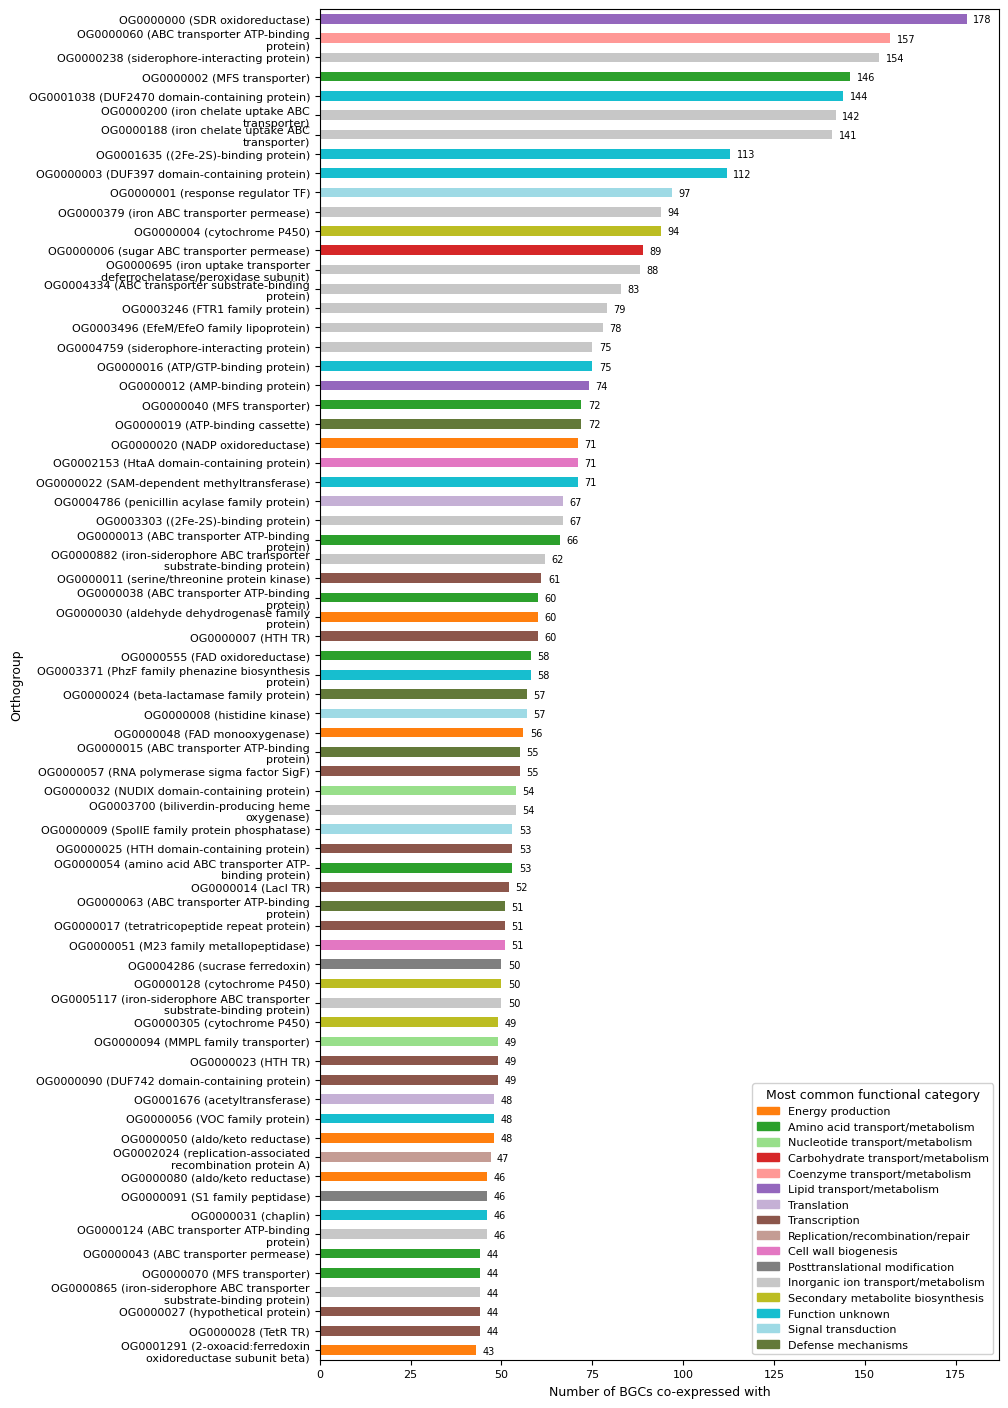

,Orthogroup,n_genes,n_BGCs,BGC_IDs,BGC_types,BGC_type_counts,top_COG,top_product,OG_label
69,OG0001291,46,43,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_50...","NI-siderophore,NI-siderophore_betalactone,NRP-...",NI-siderophore:13; NRP-metallophore_NRPS:8; am...,C,2-oxoacid:ferredoxin oxidoreductase subunit beta,OG0001291 (2-oxoacid:ferredoxin\noxidoreductas...
64,OG0000028,53,44,"NBC_00012_18_NRPS-like_NRPS,NBC_00024_7_NRP-me...","LAP_blactam_thiopeptide,LAP_thiopeptide,NI-sid...",NRPS:9; NRP-metallophore_NRPS_melanin:4; terpe...,K,TetR TR,OG0000028 (TetR TR)
65,OG0000027,55,44,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00028_18...","NI-siderophore,NRP-metallophore_NRPS,NRP-metal...",PKS-like_T1PKS_T2PKS:4; NRPS_T1PKS:4; melanin:...,K,hypothetical protein,OG0000027 (hypothetical protein)
68,OG0000865,80,44,"NBC_00101_8_NRP-metallophore_NRPS,NBC_00185_15...","NI-siderophore,NRP-metallophore_NRPS,NRP-metal...",NRP-metallophore_NRPS:40; NI-siderophore:17; N...,P,iron-siderophore ABC transporter substrate-bin...,OG0000865 (iron-siderophore ABC transporter\ns...
67,OG0000070,50,44,"NBC_00077_25_NRPS_LAP_NRPS-like,NBC_00101_4_NR...","LAP_NRPS_NRPS-like,LAP_thiopeptide,NI-sideroph...",T2PKS:7; NRPS:4; T1PKS:3; NI-siderophore:3; am...,E,MFS transporter,OG0000070 (MFS transporter)
...,...,...,...,...,...,...,...,...,...
4,OG0001038,190,144,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00024_7_...","LAP_NRPS_thiopeptide,NI-siderophore,NI-siderop...",NI-siderophore:81; NRP-metallophore_NRPS:61; a...,S,DUF2470 domain-containing protein,OG0001038 (DUF2470 domain-containing protein)
3,OG0000002,189,146,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_10...","LAP_NRPS-like_T1PKS_other,LAP_NRPS_NRPS-like,L...",T1PKS:22; NRPS:14; T2PKS:12; NI-siderophore:10...,E,MFS transporter,OG0000002 (MFS transporter)
2,OG0000238,207,154,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_50...","LAP_NRPS_thiopeptide,LAP_thiopeptide,NI-sidero...",NI-siderophore:78; NRP-metallophore_NRPS:73; a...,P,siderophore-interacting protein,OG0000238 (siderophore-interacting protein)
1,OG0000060,338,157,"NBC_00001_23_NI-siderophore,NBC_00003_50_NI-si...",LAP_NRP-metallophore_NRPS_RRE-containing_thiop...,NRP-metallophore_NRPS:132; NI-siderophore:107;...,H,ABC transporter ATP-binding protein,OG0000060 (ABC transporter ATP-binding\nprotein)


In [442]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from textwrap import fill

TOP_N = 70

# --------------------------------------------------
# SOURCE OF TRUTH: use the already computed summary
# --------------------------------------------------
summary = orthogroup_bgc_summary.copy()

# Exclude Singleton here so counts stay otherwise identical
summary = summary[summary["Orthogroup"].astype(str).str.strip() != "Singleton"].copy()

# --------------------------------------------------
# Metadata for label + color
# IMPORTANT: use same Orthogroup-only filter as your summary block
# --------------------------------------------------
meta = df[df["Orthogroup"].notna()].copy()
meta = meta[meta["Orthogroup"].astype(str).str.strip() != "Singleton"].copy()

meta["Product"] = meta["Product"].astype("string").str.strip()

bad_products = {"", "-", "nan", "none", "na", "null", "<na>"}
meta.loc[
    meta["Product"].notna() & meta["Product"].str.lower().isin(bad_products),
    "Product"
] = pd.NA

meta["Product_short"] = meta["Product"].replace(PRODUCT_RENAME)

meta["COG1"] = (
    meta.get("COG_category", pd.Series([pd.NA] * len(meta), index=meta.index))
        .astype("string")
        .str.extract(r"([A-Z])", expand=False)
        .fillna("NA")
)

def safe_mode(series, default="unknown"):
    s = series.dropna()
    if s.empty:
        return default
    return s.value_counts().idxmax()

og_top_cog = (
    meta.groupby("Orthogroup")["COG1"]
        .apply(lambda s: safe_mode(s, default="NA"))
        .reset_index(name="top_COG")
)

og_top_product = (
    meta.groupby("Orthogroup")["Product_short"]
        .apply(lambda s: safe_mode(s, default="unknown"))
        .reset_index(name="top_product")
)

summary = (
    summary
    .merge(og_top_cog, on="Orthogroup", how="left")
    .merge(og_top_product, on="Orthogroup", how="left")
)

summary["top_COG"] = summary["top_COG"].fillna("NA")
summary["top_product"] = summary["top_product"].fillna("unknown")

# --------------------------------------------------
# Plot top N from the summary itself
# --------------------------------------------------
topN = summary.head(TOP_N).sort_values("n_BGCs", ascending=True).copy()

topN["OG_label"] = (
    topN["Orthogroup"].astype(str)
    + " ("
    + topN["top_product"].astype(str)
    + ")"
).apply(lambda s: fill(s, width=45))

bar_colors = [COG_COLOR.get(c, COG_COLOR["NA"]) for c in topN["top_COG"]]

fig_h = max(7, 0.20 * len(topN))
fig, ax = plt.subplots(figsize=(10, fig_h))

bars = ax.barh(
    topN["OG_label"],
    topN["n_BGCs"],
    color=bar_colors,
    height=0.50,
    edgecolor="none"
)

ax.set_xlabel("Number of BGCs co-expressed with", fontsize=9)
ax.set_ylabel("Orthogroup", fontsize=9)

ax.margins(y=0.03)
ax.set_ylim(-0.5, len(topN) - 0.5)

x_offset = max(topN["n_BGCs"]) * 0.01 if len(topN) > 0 else 0.1
for b in bars:
    w = b.get_width()
    y_top = b.get_y() + b.get_height() - 0.02
    ax.text(w + x_offset, y_top, f"{int(w)}", va="top", ha="left", fontsize=7)

present_cogs = list(pd.unique(topN["top_COG"]))
handles = [
    mpatches.Patch(
        color=COG_COLOR.get(c, COG_COLOR["NA"]),
        label=COG_FULLNAME.get(c, "Unassigned / no COG")
    )
    for c in COG_ORDER
    if c in present_cogs
]

ax.legend(
    handles=handles,
    title="Most common functional category",
    loc="lower right",
    frameon=True,
    framealpha=0.9,
    fontsize=8,
    title_fontsize=9
)

ax.tick_params(axis="y", labelsize=8)
ax.tick_params(axis="x", labelsize=8)

plt.tight_layout(pad=0.4)
plt.savefig("Top70_orthogroups_BGCs_noSingleton.png", dpi=350, bbox_inches="tight")
plt.show()

topN

In [443]:
summary_og.head()

,Orthogroup,n_BGCs,n_genes,top_COG,top_product
0,Singleton,379,800,S,hypothetical protein
1,OG0000000,178,182,I,SDR oxidoreductase
2,OG0000060,157,221,H,ABC transporter ATP-binding protein
3,OG0000238,154,130,P,siderophore-interacting protein
4,OG0000002,148,162,E,MFS transporter


In [460]:
summary_og[summary_og["Orthogroup"].astype(str).str.contains("27", na=False)]

,Orthogroup,n_BGCs,n_genes,top_COG,top_product
43,OG0000027,53,69,K,hypothetical protein
146,OG0000127,30,33,T,TerD family protein
152,OG0000270,30,27,H,family 2 encapsulin nanocompartment cargo prot...
179,OG0000227,28,28,E,SGNH/GDSL hydrolase family protein
185,OG0002527,28,17,O,Fe-S cluster assembly protein SufD
...,...,...,...,...,...
11478,OG0027544,1,1,NA,hypothetical protein
11479,OG0027549,1,1,NA,IS5 family transposase
11480,OG0027569,1,1,NA,hypothetical protein
11481,OG0027591,1,1,E,3-isopropylmalate dehydratase large subunit


In [461]:
bgc_modules_filtered.head()

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cand_Cluster_7,Cluster_Product_7,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup,relevant_BGC_ID
0,OHB55_00010,hypothetical protein,100.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Singleton,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840,NBC_01734_17_T3PKS
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851,NBC_01734_4_RRE-containing_NRP-metallophore_NR...
4,OHB55_00205,hypothetical protein,75.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0008630,NBC_01734_4_RRE-containing_NRP-metallophore_NR...


In [462]:
summary_og

,Orthogroup,n_BGCs,n_genes,top_COG,top_product
0,Singleton,379,800,S,hypothetical protein
1,OG0000000,178,182,I,SDR oxidoreductase
2,OG0000060,157,221,H,ABC transporter ATP-binding protein
3,OG0000238,154,130,P,siderophore-interacting protein
4,OG0000002,148,162,E,MFS transporter
...,...,...,...,...,...
11478,OG0027544,1,1,NA,hypothetical protein
11479,OG0027549,1,1,NA,IS5 family transposase
11480,OG0027569,1,1,NA,hypothetical protein
11481,OG0027591,1,1,E,3-isopropylmalate dehydratase large subunit


In [463]:
import pandas as pd

df = bgc_modules_filtered.copy()

# -----------------------------
# 1) Keep only rows with ≥1 BGC
# -----------------------------
df = df[df["relevant_BGC_ID"].notna()].copy()

# -----------------------------
# 2) Clean strings
# -----------------------------
for col in ["Product", "Orthogroup", "relevant_BGC_ID"]:
    df[col] = df[col].astype("string").str.strip()

# -----------------------------
# 3) Split & explode multiple BGCs
#    Handles: "A,B" and "A, B"
# -----------------------------
df["relevant_BGC_ID"] = df["relevant_BGC_ID"].str.split(r"\s*,\s*")
df = df.explode("relevant_BGC_ID", ignore_index=True)

# Remove empty strings after exploding
df["relevant_BGC_ID"] = df["relevant_BGC_ID"].astype("string").str.strip()
df = df[df["relevant_BGC_ID"].notna() & (df["relevant_BGC_ID"] != "")].copy()

# -----------------------------
# 4) Optional: remove hypothetical proteins (product-level only)
# -----------------------------
df = df[df["Product"].str.lower() != "hypothetical protein"].copy()

# -----------------------------
# 5) Extract BGC type from ID
#    Example:
#    NBC_01734_17_T3PKS           -> T3PKS
#    NBC_00001_2_NRP-metallophore_NRPS -> NRP-metallophore_NRPS
# -----------------------------
df["BGC_type"] = (
    df["relevant_BGC_ID"]
    .str.split("_", n=3)
    .str[3]
)

# Safety: drop rows where parsing failed
df = df[df["BGC_type"].notna()].copy()


In [464]:
df

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cluster_Product_7,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup,relevant_BGC_ID,BGC_type
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,RRE-containing_NRP-metallophore_NRPS_T1PKS
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840,NBC_01734_17_T3PKS,T3PKS
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,RRE-containing_NRP-metallophore_NRPS_T1PKS
7,OHB55_00250,threonine/serine dehydratase,313.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0005006,NBC_01734_5_RRE-containing_NRP-metallophore_NR...,RRE-containing_NRP-metallophore_NRPS_T1PKS
9,OHB55_00320,phage Gp37/Gp68 family protein,251.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0008945,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,RRE-containing_NRP-metallophore_NRPS_T1PKS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61640,OIE62_38505,GNAT family N-acetyltransferase,36.0,unknown,False,33.0,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0001271,NBC_01770_18_ectoine,ectoine
61643,OIE62_40710,TauD/TfdA family dioxygenase,333.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0001597,NBC_01770_18_ectoine,ectoine
61644,OIE62_40715,FAD-binding protein,517.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0012951,NBC_01770_18_ectoine,ectoine
61645,OIE62_40720,glycosyltransferase family 4 protein,417.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0017394,NBC_01770_18_ectoine,ectoine


In [465]:
def normalize_bgc_type(bgc_type):
    if pd.isna(bgc_type):
        return pd.NA
    parts = str(bgc_type).split("_")
    parts = sorted(parts)
    return "_".join(parts)

df["BGC_type"] = df["BGC_type"].apply(normalize_bgc_type)


In [466]:
df

,Geneid,Product,Sequence_Length,Gene_Kind,Is_Core_Gene,Region_Nr,corr_to_bgc,expressed_any,high_corr,refined_member,...,Cluster_Product_7,Cand_Cluster_8,Cluster_Product_8,Cand_Cluster_9,Cluster_Product_9,Cand_Cluster_10,Cluster_Product_10,Orthogroup,relevant_BGC_ID,BGC_type
1,OHB55_00055,DUF5667 domain-containing protein,289.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0002919,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS
2,OHB55_00125,GNAT family N-acetyltransferase,338.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0003840,NBC_01734_17_T3PKS,T3PKS
3,OHB55_00190,NUDIX hydrolase,188.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0000851,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS
7,OHB55_00250,threonine/serine dehydratase,313.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0005006,NBC_01734_5_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS
9,OHB55_00320,phage Gp37/Gp68 family protein,251.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0008945,NBC_01734_4_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61640,OIE62_38505,GNAT family N-acetyltransferase,36.0,unknown,False,33.0,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0001271,NBC_01770_18_ectoine,ectoine
61643,OIE62_40710,TauD/TfdA family dioxygenase,333.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0001597,NBC_01770_18_ectoine,ectoine
61644,OIE62_40715,FAD-binding protein,517.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0012951,NBC_01770_18_ectoine,ectoine
61645,OIE62_40720,glycosyltransferase family 4 protein,417.0,NaN,False,NaN,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OG0017394,NBC_01770_18_ectoine,ectoine


In [467]:
def bgc_type_counts(series):
    vc = series.value_counts()
    return "; ".join(f"{k}:{v}" for k, v in vc.items())


In [468]:

# -------------------------
# PRODUCT summary
# -------------------------
product_bgc_summary = (
    df.groupby("Product", dropna=False)
      .agg(
          n_genes=("Geneid", "count"),
          n_BGCs=("relevant_BGC_ID", "nunique"),
          BGC_IDs=("relevant_BGC_ID", lambda x: ",".join(sorted(set(x.dropna())))),
          BGC_types=("BGC_type", lambda x: ",".join(sorted(set(x.dropna())))),
          BGC_type_counts=("BGC_type", bgc_type_counts),
      )
      .reset_index()
      .sort_values("n_BGCs", ascending=False)
)

product_bgc_summary.head()


,Product,n_genes,n_BGCs,BGC_IDs,BGC_types,BGC_type_counts
1399,MFS transporter,896,459,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_10...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRPS:64; T2PKS:52; T1PKS:51; NI-siderophore:48...
217,ABC transporter ATP-binding protein,801,418,"NBC_00001_23_NI-siderophore,NBC_00003_22_thioa...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRP-metallophore_NRPS:112; NI-siderophore:101;...
220,ABC transporter permease,684,364,"NBC_00001_22_thioamitides,NBC_00001_23_NI-side...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",terpene:44; NRPS:44; T1PKS:36; NI-siderophore:...
1159,GNAT family N-acetyltransferase,620,347,"NBC_00003_10_NRPS-like_T3PKS,NBC_00003_50_NI-s...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NI-siderophore:50; NRP-metallophore_NRPS:49; N...
223,ABC transporter substrate-binding protein,510,324,"NBC_00001_22_thioamitides,NBC_00001_26_ectoine...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRP-metallophore_NRPS:68; NI-siderophore:63; N...


In [469]:
# -------------------------
# ORTHOGROUP summary
# -------------------------
orthogroup_bgc_summary = (
    df[df["Orthogroup"].notna()]
    .groupby("Orthogroup")
    .agg(
        n_genes=("Geneid", "count"),
        n_BGCs=("relevant_BGC_ID", "nunique"),
        BGC_IDs=("relevant_BGC_ID", lambda x: ",".join(sorted(set(x.dropna())))),
        BGC_types=("BGC_type", lambda x: ",".join(sorted(set(x.dropna())))),
        BGC_type_counts=("BGC_type", bgc_type_counts),
    )
    .reset_index()
    .sort_values("n_BGCs", ascending=False)
)

orthogroup_bgc_summary.head()


,Orthogroup,n_genes,n_BGCs,BGC_IDs,BGC_types,BGC_type_counts
0,OG0000000,217,178,"NBC_00003_22_thioamide-NRP_NRPS_ladderane,NBC_...","2dos_NRPS-like_T1PKS,CDPS_NRPS-like_lanthipept...",NI-siderophore:16; T2PKS:14; NRPS:14; NRP-meta...
60,OG0000060,338,157,"NBC_00001_23_NI-siderophore,NBC_00003_50_NI-si...",LAP_NRP-metallophore_NRPS_RRE-containing_thiop...,NRP-metallophore_NRPS:132; NI-siderophore:107;...
237,OG0000238,207,154,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_50...","LAP_NRPS_thiopeptide,LAP_thiopeptide,NI-sidero...",NI-siderophore:78; NRP-metallophore_NRPS:73; a...
2,OG0000002,189,146,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_10...","LAP_NRPS-like_T1PKS_other,LAP_NRPS_NRPS-like,L...",T1PKS:22; NRPS:14; T2PKS:12; NI-siderophore:10...
1018,OG0001038,190,144,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00024_7_...","LAP_NRPS_thiopeptide,NI-siderophore,NI-siderop...",NI-siderophore:81; NRP-metallophore_NRPS:61; a...


In [470]:
product_bgc_type_long = (
    df.groupby(["Product", "BGC_type"])
      .size()
      .reset_index(name="count")
      .sort_values(["Product", "count"], ascending=[True, False])
)

product_bgc_type_long.head()


,Product,BGC_type,count
0,"(2,3-dihydroxybenzoyl)adenylate synthase",NRP-metallophore_NRPS,1
1,"(2,3-dihydroxybenzoyl)adenylate synthase",NRP-metallophore_NRPS_betalactone,1
4,(2Fe-2S) ferredoxin domain-containing protein,T2PKS_thiopeptide,2
2,(2Fe-2S) ferredoxin domain-containing protein,PKS-like,1
3,(2Fe-2S) ferredoxin domain-containing protein,T1PKS_hglE-KS_lassopeptide,1


In [471]:
orthogroup_bgc_type_long = (
    df[df["Orthogroup"].notna()]
    .groupby(["Orthogroup", "BGC_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["Orthogroup", "count"], ascending=[True, False])
)

orthogroup_bgc_type_long.head()

,Orthogroup,BGC_type,count
5,OG0000000,NI-siderophore,16
14,OG0000000,NRPS,14
64,OG0000000,T2PKS,14
10,OG0000000,NRP-metallophore_NRPS,10
93,OG0000000,terpene,8


In [472]:
orthogroup_bgc_summary

,Orthogroup,n_genes,n_BGCs,BGC_IDs,BGC_types,BGC_type_counts
0,OG0000000,217,178,"NBC_00003_22_thioamide-NRP_NRPS_ladderane,NBC_...","2dos_NRPS-like_T1PKS,CDPS_NRPS-like_lanthipept...",NI-siderophore:16; T2PKS:14; NRPS:14; NRP-meta...
60,OG0000060,338,157,"NBC_00001_23_NI-siderophore,NBC_00003_50_NI-si...",LAP_NRP-metallophore_NRPS_RRE-containing_thiop...,NRP-metallophore_NRPS:132; NI-siderophore:107;...
237,OG0000238,207,154,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_50...","LAP_NRPS_thiopeptide,LAP_thiopeptide,NI-sidero...",NI-siderophore:78; NRP-metallophore_NRPS:73; a...
2,OG0000002,189,146,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_10...","LAP_NRPS-like_T1PKS_other,LAP_NRPS_NRPS-like,L...",T1PKS:22; NRPS:14; T2PKS:12; NI-siderophore:10...
1018,OG0001038,190,144,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00024_7_...","LAP_NRPS_thiopeptide,NI-siderophore,NI-siderop...",NI-siderophore:81; NRP-metallophore_NRPS:61; a...
...,...,...,...,...,...,...
6464,OG0008856,1,1,NBC_00440_21_terpene,terpene,terpene:1
6463,OG0008850,2,1,NBC_01734_5_RRE-containing_NRP-metallophore_NR...,NRP-metallophore_NRPS_RRE-containing_T1PKS,NRP-metallophore_NRPS_RRE-containing_T1PKS:2
4187,OG0004629,1,1,NBC_01092_25_furan,furan,furan:1
6458,OG0008843,1,1,NBC_01281_31_melanin,melanin,melanin:1


In [473]:
orthogroup_product_bgc_summary = pd.merge(orthogroup_bgc_summary, summary_og, how = 'left', on = 'Orthogroup')

In [474]:
with pd.ExcelWriter("BGC_coexpression_summaries.xlsx") as writer:
    product_bgc_summary.to_excel(writer, sheet_name="Product_summary", index=False)
    orthogroup_bgc_summary.to_excel(writer, sheet_name="Orthogroup_summary", index=False)
    product_bgc_type_long.to_excel(writer, sheet_name="Product_BGCtype_long", index=False)
    orthogroup_bgc_type_long.to_excel(writer, sheet_name="Orthogroup_BGCtype_long", index=False)
    orthogroup_product_bgc_summary.to_excel(writer, sheet_name="Orthogroup_summary_product", index=False)


In [475]:
product_bgc_summary.head()

,Product,n_genes,n_BGCs,BGC_IDs,BGC_types,BGC_type_counts
1399,MFS transporter,896,459,"NBC_00001_2_NRP-metallophore_NRPS,NBC_00003_10...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRPS:64; T2PKS:52; T1PKS:51; NI-siderophore:48...
217,ABC transporter ATP-binding protein,801,418,"NBC_00001_23_NI-siderophore,NBC_00003_22_thioa...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRP-metallophore_NRPS:112; NI-siderophore:101;...
220,ABC transporter permease,684,364,"NBC_00001_22_thioamitides,NBC_00001_23_NI-side...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",terpene:44; NRPS:44; T1PKS:36; NI-siderophore:...
1159,GNAT family N-acetyltransferase,620,347,"NBC_00003_10_NRPS-like_T3PKS,NBC_00003_50_NI-s...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NI-siderophore:50; NRP-metallophore_NRPS:49; N...
223,ABC transporter substrate-binding protein,510,324,"NBC_00001_22_thioamitides,NBC_00001_26_ectoine...","2dos_NRPS-like_T1PKS,2dos_NRPS_NRPS-like_T1PKS...",NRP-metallophore_NRPS:68; NI-siderophore:63; N...


### Fishers test for significantly enriched BGC_types (product)

In [476]:
bgc_df = bgc_modules.copy()

# keep only real BGCs
bgc_df = bgc_df[
    bgc_df["refined_BGC_ID"].notna() &
    bgc_df["Strain"].notna()
].copy()

# normalize BGC types
bgc_df["BGC_type_norm"] = (
    bgc_df["Cluster_Product_1"]
    .astype(str)
    .str.replace(", ", "_", regex=False)
    .str.replace(",", "_", regex=False)
)

# one row = one distinct BGC
bgc_universe = (
    bgc_df[["Strain", "refined_BGC_ID", "BGC_type_norm"]]
    .drop_duplicates()
)

total_bgcs = bgc_universe.shape[0]

bgc_type_totals = (
    bgc_universe
    .dropna(subset=["BGC_type_norm"])
    ["BGC_type_norm"]
    .value_counts()
)



In [477]:
bgc_type_totals

BGC_type_norm
nan                                                           268
terpene                                                       209
NI-siderophore                                                142
NRPS                                                          106
T1PKS                                                          75
                                                             ... 
thioamide-NRP_butyrolactone                                     1
NRPS_betalactone_T3PKS_NRPS-like_ectoine_T1PKS_transAT-PKS      1
hserlactone                                                     1
NRPS_T1PKS_2dos                                                 1
prodigiosin_NRPS_butyrolactone                                  1
Name: count, Length: 456, dtype: int64

In [478]:
total_bgcs_across_types = bgc_type_totals.sum()
total_bgcs_across_types


2329

In [479]:
import pandas as pd
from scipy.stats import fisher_exact
import statsmodels.stats.multitest as smm

In [480]:
df = product_bgc_type_long.copy()

# Totals
total_bgcs = df["count"].sum()
product_totals = df.groupby("Product")["count"].sum()
type_totals = df.groupby("BGC_type")["count"].sum()

In [481]:
from scipy.stats import fisher_exact
import statsmodels.stats.multitest as smm

rows = []

for _, r in df.iterrows():
    product = r["Product"]
    bgc_type = r["BGC_type"]
    a = r["count"]   # BGCs with this Product AND this BGC type

    # Skip unstable cases
    if a < 1:
        continue
    if product not in product_totals:
        continue
    if bgc_type not in bgc_type_totals:
        continue

    # --- CONTINGENCY TABLE ---
    # a = product ∩ bgc_type
    b = product_totals[product] - a          # product & other BGC types
    c = bgc_type_totals[bgc_type] - a        # bgc_type & other products
    d = total_bgcs - a - b - c               # neither

    # Guard against invalid tables
    if min(a, b, c, d) < 0:
        continue

    odds_ratio, pval = fisher_exact(
        [[a, b],
         [c, d]],
        alternative="greater"
    )

    rows.append({
        "Product": product,
        "BGC_type": bgc_type,
        "count": a,
        "product_total": product_totals[product],
        "bgc_type_total": bgc_type_totals[bgc_type],
        "odds_ratio": odds_ratio,
        "p_value": pval
    })

results_df = pd.DataFrame(rows)

# -----------------------------
# Multiple testing correction
# -----------------------------
if not results_df.empty:
    results_df["FDR"] = smm.multipletests(
        results_df["p_value"],
        method="fdr_bh"
    )[1]

    results_df = results_df.sort_values(
        ["FDR", "odds_ratio"],
        ascending=[True, False]
    ).reset_index(drop=True)


In [482]:
results_df.head()

,Product,BGC_type,count,product_total,bgc_type_total,odds_ratio,p_value,FDR
0,siderophore-interacting protein,NI-siderophore,108,287,142,910.635557,1.535731e-221,3.445106e-217
1,iron chelate uptake ABC transporter family per...,NI-siderophore,103,296,142,702.020194,2.641134e-205,2.962428e-201
2,DUF2470 domain-containing protein,NI-siderophore,83,193,142,657.157935,1.336960e-170,9.997338e-167
3,iron ABC transporter permease,NI-siderophore,85,296,142,362.446163,8.673670e-157,4.864411e-153
4,DUF2470 domain-containing protein,NRP-metallophore_NRPS,62,193,65,8115.374046,2.275975e-151,1.021139e-147


In [483]:
filtered_results = results_df[
    (results_df["FDR"] < 0.01) &
    (results_df["count"] >= 5) &
    (results_df["count"] / results_df["bgc_type_total"] >= 0.10)
].copy()


In [484]:
filtered_results.head()

,Product,BGC_type,count,product_total,bgc_type_total,odds_ratio,p_value,FDR
0,siderophore-interacting protein,NI-siderophore,108,287,142,910.635557,1.535731e-221,3.445106e-217
1,iron chelate uptake ABC transporter family per...,NI-siderophore,103,296,142,702.020194,2.641134e-205,2.962428e-201
2,DUF2470 domain-containing protein,NI-siderophore,83,193,142,657.157935,1.336960e-170,9.997338e-167
3,iron ABC transporter permease,NI-siderophore,85,296,142,362.446163,8.673670e-157,4.864411e-153
4,DUF2470 domain-containing protein,NRP-metallophore_NRPS,62,193,65,8115.374046,2.275975e-151,1.021139e-147


In [485]:
filtered_results.to_excel('BGC_type_gene_enrichment_product.xlsx')

In [486]:
# bgc_type_totals: index = BGC_type, value = number of distinct BGCs
major_types = (
    bgc_type_totals
    .sort_values(ascending=False)
    .head(8)   # ← 5–7 is ideal for a figure
    .index
    .tolist()
)


In [487]:
major_types

['nan',
 'terpene',
 'NI-siderophore',
 'NRPS',
 'T1PKS',
 'NRP-metallophore_NRPS',
 'ectoine',
 'RiPP-like']

In [488]:
filtered_major = filtered_results[
    filtered_results["BGC_type"].isin(major_types)
].copy()


In [489]:
filtered_major

,Product,BGC_type,count,product_total,bgc_type_total,odds_ratio,p_value,FDR
0,siderophore-interacting protein,NI-siderophore,108,287,142,910.635557,1.535731e-221,3.445106e-217
1,iron chelate uptake ABC transporter family per...,NI-siderophore,103,296,142,702.020194,2.641134e-205,2.962428e-201
2,DUF2470 domain-containing protein,NI-siderophore,83,193,142,657.157935,1.336960e-170,9.997338e-167
3,iron ABC transporter permease,NI-siderophore,85,296,142,362.446163,8.673670e-157,4.864411e-153
4,DUF2470 domain-containing protein,NRP-metallophore_NRPS,62,193,65,8115.374046,2.275975e-151,1.021139e-147
...,...,...,...,...,...,...,...,...
1125,FAD-dependent oxidoreductase,RiPP-like,6,229,54,28.789238,1.540161e-07,3.068423e-06
1231,GNAT family N-acetyltransferase,RiPP-like,8,620,54,14.484513,2.643457e-07,4.813366e-06
1444,ATP-binding protein,RiPP-like,7,487,54,15.856427,7.678602e-07,1.192070e-05
1532,class I SAM-dependent methyltransferase,ectoine,6,294,59,20.161164,1.131989e-06,1.656485e-05


In [490]:
top_per_type = (
    filtered_major
    .sort_values("odds_ratio", ascending=False)
    .groupby("BGC_type")
    .head(10)   # 8–15 per type works well
)


In [491]:
heatmap_df = (
    top_per_type
    .assign(logOR=lambda x: np.log10(x["odds_ratio"]))
    .pivot_table(
        index="Product",
        columns="BGC_type",
        values="logOR",
        aggfunc="max"
    )
    .clip(upper=4)
)


In [492]:
top_per_type

,Product,BGC_type,count,product_total,bgc_type_total,odds_ratio,p_value,FDR
4,DUF2470 domain-containing protein,NRP-metallophore_NRPS,62,193,65,8115.374046,2.275975e-151,1.021139e-147
7,(2Fe-2S)-binding protein,NRP-metallophore_NRPS,57,234,65,2068.866525,7.533697e-128,2.112543e-124
11,heme ABC transporter ATP-binding protein,NRP-metallophore_NRPS,35,78,65,1398.073643,6.195971e-85,1.158285e-81
19,biliverdin-producing heme oxygenase,NRP-metallophore_NRPS,25,54,65,1110.840517,2.511458e-60,2.816977e-57
0,siderophore-interacting protein,NI-siderophore,108,287,142,910.635557,1.535731e-221,3.445106e-217
...,...,...,...,...,...,...,...,...
51,ABC transporter permease,terpene,44,684,209,21.161667,2.718980e-39,1.172979e-36
70,TetR/AcrR family transcriptional regulator,terpene,36,557,209,20.332753,3.232211e-32,1.021242e-29
131,response regulator transcription factor,terpene,25,388,209,19.113442,1.504066e-22,2.556114e-20
140,SDR family oxidoreductase,terpene,25,426,209,17.289317,1.465450e-21,2.331521e-19


In [493]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from textwrap import wrap

# -----------------------------
# PREP
# -----------------------------
df_plot = top_per_type.copy()

df_plot["logOR"] = np.log10(df_plot["odds_ratio"].astype(float))
CAP = 4.0
df_plot["logOR"] = df_plot["logOR"].clip(upper=CAP)

bgc_types = [
    "terpene", "NI-siderophore", "NRPS", "T1PKS",
    "NRP-metallophore_NRPS", "ectoine", "RiPP-like", "T2PKS"
]
df_plot = df_plot[df_plot["BGC_type"].isin(bgc_types)].copy()

# optional ordering
type_strength = (
    df_plot.groupby("BGC_type")["logOR"]
    .quantile(0.90)
    .sort_values(ascending=False)
)
bgc_types = type_strength.index.tolist()

# -----------------------------
# Label formatter: FULL TEXT, allow up to 3 lines, NO truncation
# -----------------------------
def format_product_label_full(prod, count=None, width=26, max_lines=3):
    s = str(prod)
    if "PRODUCT_RENAME" in globals():
        s = PRODUCT_RENAME.get(s, s)

    if count is not None and pd.notna(count):
        s = f"{s} ({int(count)})"

    lines = wrap(s, width=width)

    # NO truncation: keep full text, just wrap
    if max_lines is None:
        return "\n".join(lines)

    # If you truly want "even if it has to be 3 lines", keep at most 3 lines,
    # but DO NOT cut content -> we increase wrap width if it would exceed max_lines.
    # This preserves full text without truncation by making lines longer.
    if len(lines) <= max_lines:
        return "\n".join(lines)

    # Increase width until it fits in max_lines (still full text)
    w = width
    while True:
        w += 2
        lines2 = wrap(s, width=w)
        if len(lines2) <= max_lines or w >= 120:
            return "\n".join(lines2)

# global scale (recommended for comparability across types)
vmin = 0
vmax = float(df_plot["logOR"].max())
norm = Normalize(vmin=vmin, vmax=vmax)

# -----------------------------
# FUNCTION: plot ONE BGC type
# -----------------------------
def plot_one_type(
    df_plot: pd.DataFrame,
    bgc_type: str,
    vmin: float,
    vmax: float,
    cmap: str = "icefire",
    label_wrap_width: int = 26,
    label_max_lines: int = 3,   # <-- 3 lines allowed
    figsize=(6.2, 6.2),         # <-- taller to accommodate 3-line labels
    dpi=300,
    savepath: str | None = None
):
    sub = df_plot[df_plot["BGC_type"] == bgc_type].copy().sort_values("logOR", ascending=False)

    # build labels (FULL text, no truncation)
    if "count" in sub.columns:
        sub["Product_label"] = [
            format_product_label_full(p, cnt, width=label_wrap_width, max_lines=label_max_lines)
            for p, cnt in zip(sub["Product"], sub["count"])
        ]
    else:
        sub["Product_label"] = [
            format_product_label_full(p, None, width=label_wrap_width, max_lines=label_max_lines)
            for p in sub["Product"]
        ]

    mat = sub.set_index("Product_label")[["logOR"]]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        linewidths=0.3,
        linecolor="lightgray",
        cbar_kws={"label": "log10(Odds ratio)"}
    )

    ax.set_title(bgc_type, fontsize=12, pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(["log10(OR)"], rotation=0, fontsize=9)

    # y labels: a bit smaller helps 3-line labels
    ax.tick_params(axis="y", labelsize=10, pad=2)

    for lab in ax.get_yticklabels():
        lab.set_horizontalalignment("right")

    # make sure nothing is clipped
    plt.tight_layout(pad=0.8)

    if savepath:
        fig.savefig(savepath, bbox_inches="tight", pad_inches=0.05, dpi = 350)
        plt.close(fig)
    else:
        plt.show()

# -----------------------------
# LOOP: generate & save all panels
# -----------------------------
for t in bgc_types:
    safe = t.replace("/", "_").replace(" ", "_")
    plot_one_type(
        df_plot=df_plot,
        bgc_type=t,
        vmin=vmin,
        vmax=vmax,
        figsize=(6.2, 6.2),  # increase height if you still have many rows
        savepath=f"{safe}_heatmap.png"
    )


### Fishers test for significantly enriched BGC_types (orthogroup)

In [494]:
df = bgc_modules_filtered.copy()

# Keep only rows with BGCs and orthogroup assignment
df = df[df["relevant_BGC_ID"].notna() & df["Orthogroup"].notna()].copy()

# Clean strings
for col in ["Orthogroup", "Product", "relevant_BGC_ID"]:
    df[col] = df[col].astype("string").str.strip()

# Split multiple BGCs per gene
df["BGC_ID"] = df["relevant_BGC_ID"].str.split(r"\s*,\s*")
df = df.explode("BGC_ID")

# Extract BGC type from BGC_ID
df["BGC_type"] = (
    df["BGC_ID"]
    .str.split("_", n=3)
    .str[3]
)


In [495]:
df_unique = (
    df[["Orthogroup", "Product", "BGC_ID", "BGC_type"]]
    .drop_duplicates()
)


In [496]:
orthogroup_bgc_type_long = (
    df_unique
    .groupby(["Orthogroup", "BGC_type"])
    .size()
    .reset_index(name="count")
)


In [497]:
orthogroup_totals = (
    df_unique
    .groupby("Orthogroup")["BGC_ID"]
    .nunique()
)


In [498]:
def safe_mode(series, default="unknown"):
    s = series.dropna()
    if s.empty:
        return default
    return s.value_counts().idxmax()

orthogroup_top_product = (
    df_unique
    .groupby("Orthogroup")["Product"]
    .apply(lambda s: safe_mode(s, default="unknown"))
)


In [499]:
bgc_type_totals = (
    bgc_modules
    .dropna(subset=["Strain", "refined_BGC_ID", "Cluster_Product_1"])
    .assign(
        BGC_type=lambda x: (
            x["Cluster_Product_1"]
            .str.replace(r",\s*", "_", regex=True)
        )
    )
    .drop_duplicates(subset=["Strain", "refined_BGC_ID"])
    .groupby("BGC_type")
    .size()
)


In [500]:
total_bgcs = (
    bgc_modules
    .dropna(subset=["Strain", "refined_BGC_ID"])
    .drop_duplicates(subset=["Strain", "refined_BGC_ID"])
    .shape[0]
)


In [501]:
from scipy.stats import fisher_exact
import statsmodels.stats.multitest as smm

rows = []

for _, r in orthogroup_bgc_type_long.iterrows():
    og = r["Orthogroup"]
    bgc_type = r["BGC_type"]
    a = r["count"]

    if a < 1:
        continue

    og_total = orthogroup_totals.get(og, 0)
    type_total = bgc_type_totals.get(bgc_type, 0)

    b = og_total - a
    c = type_total - a
    d = total_bgcs - a - b - c

    if min(a, b, c, d) < 0:
        continue

    odds_ratio, pval = fisher_exact([[a, b], [c, d]], alternative="greater")

    rows.append({
        "Orthogroup": og,
        "BGC_type": bgc_type,
        "count": a,
        "orthogroup_total": og_total,
        "bgc_type_total": type_total,
        "most_common_product": orthogroup_top_product.get(og, "unknown"),
        "odds_ratio": odds_ratio,
        "p_value": pval
    })

results_og = pd.DataFrame(rows)


In [502]:
results_og["FDR"] = smm.multipletests(
    results_og["p_value"],
    method="fdr_bh"
)[1]

results_og = results_og.sort_values(
    ["FDR", "odds_ratio"],
    ascending=[True, False]
).reset_index(drop=True)


In [503]:
results_og.head()

,Orthogroup,BGC_type,count,orthogroup_total,bgc_type_total,most_common_product,odds_ratio,p_value,FDR
0,OG0000188,NRP-metallophore_NRPS,62,141,65,iron chelate uptake ABC transporter family per...,507.510549,3.485101e-75,1.710139e-70
1,OG0000060,NI-siderophore,78,157,142,ABC transporter ATP-binding protein,28.740902,1.073099e-57,2.632850e-53
2,OG0000200,NRP-metallophore_NRPS,48,142,65,iron chelate uptake ABC transporter family per...,57.822278,1.788085e-45,2.924711e-41
3,OG0000188,NI-siderophore,65,141,142,iron chelate uptake ABC transporter family per...,20.726247,5.993099e-44,7.352034e-40
4,OG0001038,NRP-metallophore_NRPS,47,144,65,DUF2470 domain-containing protein,51.737686,2.101376e-43,1.718575e-39


In [504]:
filtered_results_og = results_og[
    (results_og["FDR"] < 0.01) &
    (results_og["count"] >= 5) &
    (results_og["count"] / results_og["bgc_type_total"] >= 0.10)
].copy()


In [505]:
filtered_results_og.to_excel('orthogroup_bgc_type_summary.xlsx')

In [506]:
filtered_major_og = filtered_results_og[
    filtered_results_og["BGC_type"].isin(major_types)
].copy()


In [507]:
top_per_type_og = (
    filtered_major_og
    .sort_values("odds_ratio", ascending=False)
    .groupby("BGC_type")
    .head(10)   # 8–15 per type works well
)


In [508]:
top_per_type_og

,Orthogroup,BGC_type,count,orthogroup_total,bgc_type_total,most_common_product,odds_ratio,p_value,FDR
0,OG0000188,NRP-metallophore_NRPS,62,141,65,iron chelate uptake ABC transporter family per...,507.510549,3.485101e-75,1.710139e-70
13,OG0000865,NRP-metallophore_NRPS,25,44,65,iron-siderophore ABC transporter substrate-bin...,65.789474,1.223622e-28,4.288795e-25
2,OG0000200,NRP-metallophore_NRPS,48,142,65,iron chelate uptake ABC transporter family per...,57.822278,1.788085e-45,2.924711e-41
33,OG0006998,NRP-metallophore_NRPS,13,22,65,iron chelate uptake ABC transporter family per...,55.833333,3.052742e-15,4.405825e-12
26,OG0005193,NRP-metallophore_NRPS,15,26,65,hypothetical protein,54.763636,2.818429e-17,5.122234e-14
4,OG0001038,NRP-metallophore_NRPS,47,144,65,DUF2470 domain-containing protein,51.737686,2.101376e-43,1.718575e-39
5,OG0000238,NRP-metallophore_NRPS,48,154,65,siderophore-interacting protein,50.956715,1.753214e-43,1.718575e-39
11,OG0002153,NRP-metallophore_NRPS,31,71,65,HtaA domain-containing protein,45.109559,3.000535e-31,1.226969e-27
10,OG0004334,NRP-metallophore_NRPS,34,83,65,ABC transporter substrate-binding protein,44.094799,1.993738e-33,8.893883e-30
15,OG0003700,NRP-metallophore_NRPS,25,54,65,biliverdin-producing heme oxygenase,42.887931,1.208283e-25,3.487673e-22


In [509]:
heatmap_df_og = (
    top_per_type_og
    .assign(logOR=lambda x: np.log10(x["odds_ratio"]))
    .pivot_table(
        index="Orthogroup",
        columns="BGC_type",
        values="logOR",
        aggfunc="max"
    )
    .clip(upper=4)
)


In [510]:
heatmap_df_og

BGC_type,NI-siderophore,NRP-metallophore_NRPS,T1PKS
Orthogroup,,,
OG0000060,1.458500,NaN,NaN
OG0000188,1.316521,2.705445,NaN
OG0000200,1.201975,1.762095,NaN
OG0000238,1.157912,1.707201,NaN
OG0000865,NaN,1.818156,NaN
OG0001038,1.173228,1.713807,NaN
OG0001400,1.212540,NaN,NaN
OG0001676,1.251101,NaN,NaN
OG0002153,NaN,1.654269,NaN


In [511]:
# build Orthogroup → most common Product
og_to_product = (
    top_per_type_og
    .groupby("Orthogroup")["most_common_product"]
    .agg(lambda x: x.value_counts().idxmax())
    .to_dict()
)


In [512]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import wrap

def wrap_label_3_lines(text: str, width: int = 28, max_lines: int = 3) -> str:
    """
    Wrap text into at most max_lines lines WITHOUT truncation.
    If it would exceed max_lines at the given width, we increase width until it fits.
    """
    text = str(text).replace("\n", " ")
    lines = wrap(text, width=width)

    if len(lines) <= max_lines:
        return "\n".join(lines)

    w = width
    while True:
        w += 2
        lines = wrap(text, width=w)
        if len(lines) <= max_lines or w >= 120:
            return "\n".join(lines)

def plot_orthogroup_heatmaps(
    heatmap_df_og: pd.DataFrame,
    og_to_product: dict | pd.Series | None = None,
    outdir: str = "og_heatmaps",
    vmin: float = 0.0,
    vmax: float | None = None,
    figsize=(5.2, 4.6),
    dpi: int = 300,
    sort_desc: bool = True,
    label_wrap_width: int = 28,
    label_max_lines: int = 3,
    out_ext: str = "png",  # "png" or "pdf"
):
    """
    Saves one 1-column heatmap per BGC type (each column in heatmap_df_og).

    - heatmap_df_og: index=Orthogroup, columns=BGC types, values=log10(OR) (NaN allowed)
    - og_to_product: mapping Orthogroup -> Product (dict or Series); if None, labels are just Orthogroup
    - y labels are wrapped to <= label_max_lines lines, without truncating text
    """

    os.makedirs(outdir, exist_ok=True)

    # Normalize product map
    if og_to_product is not None and isinstance(og_to_product, pd.Series):
        og_to_product = og_to_product.to_dict()

    # Coerce matrix to numeric
    df = heatmap_df_og.copy()
    df.index = df.index.astype(str)
    df.columns = df.columns.astype(str)
    df = df.apply(pd.to_numeric, errors="coerce")

    # Determine vmax if not provided
    arr = df.to_numpy()
    if vmax is None:
        if np.isfinite(arr).any():
            vmax = float(np.nanmax(arr))
        else:
            print("No numeric values found in heatmap_df_og — nothing to plot.")
            return

    # Colormap
    cmap = sns.color_palette("icefire", as_cmap=True)

    saved = 0

    for bgc_type in df.columns:
        mat = df[[bgc_type]].dropna()

        if sort_desc and not mat.empty:
            mat = mat.sort_values(by=bgc_type, ascending=False)

        if mat.empty:
            print(f"Skipping '{bgc_type}': no non-NaN values.")
            continue

        # Build y labels: Orthogroup (Product) and wrap to <=3 lines (no truncation)
        labels = []
        for og in mat.index:
            if og_to_product is not None and og in og_to_product and pd.notna(og_to_product[og]):
                full_label = f"{og} ({og_to_product[og]})"
            else:
                full_label = og

            labels.append(
                wrap_label_3_lines(full_label, width=label_wrap_width, max_lines=label_max_lines)
            )

        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

        sns.heatmap(
            mat,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            cbar=True,
            linewidths=0.3,
            linecolor="lightgray",
            cbar_kws={"label": "log10(Odds ratio)"},
        )

        ax.set_title(bgc_type, fontsize=12, pad=8)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(["log10(OR)"], rotation=0, fontsize=9)

        # Apply wrapped labels
        ax.set_yticks(np.arange(len(labels)) + 0.5)
        ax.set_yticklabels(labels, fontsize=8)
        ax.tick_params(axis="y", pad=2)

        for lab in ax.get_yticklabels():
            lab.set_horizontalalignment("right")

        plt.tight_layout(pad=0.8)

        safe = bgc_type.replace("/", "_").replace(" ", "_")
        path = os.path.join(outdir, f"{safe}_OG_heatmap.{out_ext}")
        fig.savefig(path, bbox_inches="tight", pad_inches=0.05)
        plt.close(fig)

        saved += 1
        print(f"Saved: {path}  (n={mat.shape[0]})")

    print(f"Done. Saved {saved} figure(s) to '{outdir}/'.")


In [513]:
plot_orthogroup_heatmaps(
    heatmap_df_og,
    og_to_product=og_to_product,  # dict or Series
    outdir="og_heatmaps"
)


Saved: og_heatmaps/NI-siderophore_OG_heatmap.png  (n=10)
Saved: og_heatmaps/NRP-metallophore_NRPS_OG_heatmap.png  (n=10)
Saved: og_heatmaps/T1PKS_OG_heatmap.png  (n=1)
Done. Saved 3 figure(s) to 'og_heatmaps/'.


In [514]:
import pandas as pd

df = df.copy()  # <- replace

# 1) How many unique relevant_BGC_ID values (as-is)
n_unique_raw = df["relevant_BGC_ID"].dropna().astype(str).nunique()
print("Unique relevant_BGC_ID (raw strings):", n_unique_raw)

# 2) Check if any cells contain multiple IDs separated by commas
s = df["relevant_BGC_ID"].dropna().astype(str)
has_commas = s.str.contains(",", regex=False)
print("Rows with comma-separated relevant_BGC_ID:", int(has_commas.sum()))

if has_commas.any():
    print("\nExamples of comma-separated values:")
    print(s[has_commas].head(10).to_list())

# 3) Count unique BGC IDs after splitting on commas
split_ids = (
    df["relevant_BGC_ID"]
      .dropna()
      .astype(str)
      .str.split(",")
      .explode()
      .str.strip()
)
split_ids = split_ids[split_ids.ne("")]  # drop empty
n_unique_split = split_ids.nunique()

print("\nUnique relevant_BGC_ID (after splitting commas):", int(n_unique_split))


Unique relevant_BGC_ID (raw strings): 881
Rows with comma-separated relevant_BGC_ID: 16555

Examples of comma-separated values:
['NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_phenazine', 'NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_phenazine', 'NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_phenazine', 'NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_phenazine', 'NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_phenazine', 'NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_phenazine', 'NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_phenazine', 'NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_phenazine', 'NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_phenazine', 'NBC_00028_17_ectoine,NBC_00028_31_other_T3PKS_phenazine']

Unique relevant_BGC_ID (after splitting commas): 1024
